In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

In [2]:
DATA_PATH = Path("data/spotify_charts_2019_2023_cleaned_v2.csv")

SAMPLE_SIZE = 300000

RANDOM_STATE = 42
TEST_SIZE = 0.20

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH.resolve()}. "
        "Update DATA_PATH to point to the cleaned CSV."
    )

print("Using:", DATA_PATH.resolve())

Using: C:\Users\colin\cs4342-song-performance\backend\notebooks\data\spotify_charts_2019_2023_cleaned_v2.csv


In [3]:
FEATURES = [
    "duration_ms",
    "explicit",
    "af_danceability",
    "af_energy",
    "af_key",
    "af_loudness",
    "af_mode",
    "af_speechiness",
    "af_acousticness",
    "af_instrumentalness",
    "af_liveness",
    "af_valence",
    "af_tempo",
    "af_time_signature",
]

TARGET = "streams"

REQUIRED_COLUMNS = ["chart", TARGET] + FEATURES

print("Number of predictor features:", len(FEATURES))
print("Predictors:")
for feature in FEATURES:
    print(" -", feature)

Number of predictor features: 14
Predictors:
 - duration_ms
 - explicit
 - af_danceability
 - af_energy
 - af_key
 - af_loudness
 - af_mode
 - af_speechiness
 - af_acousticness
 - af_instrumentalness
 - af_liveness
 - af_valence
 - af_tempo
 - af_time_signature


In [4]:
dtype = {"explicit": "boolean"}

chunks = []
rows_seen = 0
rows_kept = 0

for chunk in pd.read_csv(DATA_PATH, usecols=REQUIRED_COLUMNS, dtype=dtype, chunksize=100000, iterator=True, low_memory=False):
    chunk = chunk[chunk["chart"].eq("top200")].copy()
    if chunk.empty:
        continue
    remaining = max(SAMPLE_SIZE - rows_kept, 0)
    if remaining == 0:
        break
    n = min(remaining, max(1, int(len(chunk) * 0.02)))
    if n < len(chunk):
        sampled = chunk.sample(n=n, random_state=RANDOM_STATE)
    else:
        sampled = chunk
    chunks.append(sampled)
    rows_seen += len(chunk)
    rows_kept += len(sampled)
    if rows_kept >= SAMPLE_SIZE:
        break

model_df = pd.concat(chunks, ignore_index=True)

print(f"Rows loaded for modeling: {len(model_df):,}")
print(f"Columns loaded: {len(model_df.columns)}")

Rows loaded for modeling: 263,921
Columns loaded: 16


In [5]:
model_df.info()
print()
print("Missing values:")
print(model_df.isna().sum())
print()
print("Chart values:")
print(model_df["chart"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 263921 entries, 0 to 263920
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   chart                263921 non-null  str    
 1   streams              263921 non-null  float64
 2   duration_ms          263899 non-null  float64
 3   explicit             263899 non-null  boolean
 4   af_danceability      263899 non-null  float64
 5   af_energy            263899 non-null  float64
 6   af_key               263899 non-null  float64
 7   af_loudness          263899 non-null  float64
 8   af_mode              263899 non-null  float64
 9   af_speechiness       263899 non-null  float64
 10  af_acousticness      263899 non-null  float64
 11  af_instrumentalness  263899 non-null  float64
 12  af_liveness          263899 non-null  float64
 13  af_valence           263899 non-null  float64
 14  af_tempo             263899 non-null  float64
 15  af_time_signature    263899 

In [6]:
before_drop = len(model_df)

model_df = model_df.dropna(subset=FEATURES + [TARGET]).copy()

model_df["explicit"] = model_df["explicit"].astype(int)

after_drop = len(model_df)

print(f"Rows before dropping missing values: {before_drop:,}")
print(f"Rows after dropping missing values: {after_drop:,}")
print(f"Rows removed: {before_drop - after_drop:,}")

Rows before dropping missing values: 263,921
Rows after dropping missing values: 263,899
Rows removed: 22


In [7]:
raw_streams = model_df[TARGET]
log_streams = pd.Series(np.log1p(raw_streams.to_numpy()), index=raw_streams.index, name="log_streams")

print("Raw streams:")
print(raw_streams.describe())

print("\nlog1p(streams):")
print(log_streams.describe())

Raw streams:
count    2.638990e+05
mean     5.640671e+04
std      2.111626e+05
min      1.001000e+03
25%      3.732000e+03
50%      9.789000e+03
75%      3.752100e+04
max      1.169678e+07
Name: streams, dtype: float64

log1p(streams):
count    263899.000000
mean          9.445510
std           1.553098
min           6.909753
25%           8.224967
50%           9.189117
75%          10.532683
max          16.274824
Name: log_streams, dtype: float64


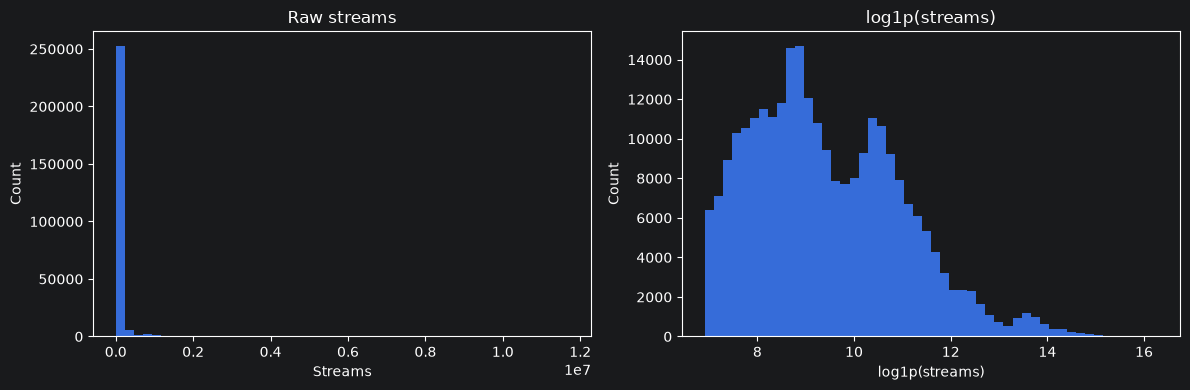

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(raw_streams, bins=50)
axes[0].set_title("Raw streams")
axes[0].set_xlabel("Streams")
axes[0].set_ylabel("Count")

axes[1].hist(log_streams, bins=50)
axes[1].set_title("log1p(streams)")
axes[1].set_xlabel("log1p(streams)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [9]:
X = model_df[FEATURES].copy()
y = np.log1p(model_df[TARGET])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (263899, 14)
y shape: (263899,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

print(f"Training observations: {len(X_train):,}")
print(f"Testing observations: {len(X_test):,}")

Training observations: 211,119
Testing observations: 52,780


In [11]:
baseline_prediction = np.full(shape=len(y_test), fill_value=y_train.mean())

baseline_r2 = float(r2_score(y_test, baseline_prediction))
baseline_mae = float(mean_absolute_error(y_test, baseline_prediction))
baseline_rmse = float(np.sqrt(mean_squared_error(y_test, baseline_prediction)))

print("Mean baseline")
print(f"R^2: {baseline_r2:.4f}")
print(f"Log MAE: {baseline_mae:.4f}")
print(f"Log RMSE: {baseline_rmse:.4f}")

Mean baseline
R^2: -0.0000
Log MAE: 1.2777
Log RMSE: 1.5514


In [12]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_prediction = linear_model.predict(X_test)

linear_r2 = r2_score(y_test, linear_prediction)
linear_mae = float(mean_absolute_error(y_test, linear_prediction))
linear_rmse = float(np.sqrt(mean_squared_error(y_test, linear_prediction)))

print("Linear Regression")
print(f"R²: {linear_r2:.4f}")
print(f"Log MAE: {linear_mae:.4f}")
print(f"Log RMSE: {linear_rmse:.4f}")

Linear Regression
R²: 0.0034
Log MAE: 1.2749
Log RMSE: 1.5487


In [13]:
linear_coefficients = (
    pd.DataFrame({
        "feature": FEATURES,
        "coefficient": linear_model.coef_,
    })
    .sort_values("coefficient", ascending=False)
)

linear_coefficients

,feature,coefficient
10,af_liveness,0.216848
1,explicit,0.117942
11,af_valence,0.113369
6,af_mode,0.071965
13,af_time_signature,0.050434
8,af_acousticness,0.048646
5,af_loudness,0.003717
4,af_key,0.001818
0,duration_ms,-0.000002
12,af_tempo,-0.000049


In [15]:
gradient_model = HistGradientBoostingRegressor(max_iter=200, learning_rate=0.10, max_leaf_nodes=31, random_state=RANDOM_STATE)

gradient_model.fit(X_train, y_train)

gradient_prediction = gradient_model.predict(X_test)

gradient_r2 = r2_score(y_test, gradient_prediction)
gradient_mae = float(mean_absolute_error(y_test, gradient_prediction))
gradient_rmse = float(np.sqrt(mean_squared_error(y_test, gradient_prediction)))

print("HistGradientBoostingRegressor")
print(f"R²: {gradient_r2:.4f}")
print(f"Log MAE: {gradient_mae:.4f}")
print(f"Log RMSE: {gradient_rmse:.4f}")

HistGradientBoostingRegressor
R²: 0.0935
Log MAE: 1.1985
Log RMSE: 1.4770


In [16]:
results = pd.DataFrame({
    "Model": [
        "Mean baseline",
        "Linear Regression",
        "Gradient Boosting",
    ],
    "R²": [
        baseline_r2,
        linear_r2,
        gradient_r2,
    ],
    "Log MAE": [
        baseline_mae,
        linear_mae,
        gradient_mae,
    ],
    "Log RMSE": [
        baseline_rmse,
        linear_rmse,
        gradient_rmse,
    ],
})

results

,Model,R²,Log MAE,Log RMSE
0,Mean baseline,-0.000008,1.277704,1.551353
1,Linear Regression,0.003431,1.274874,1.548683
2,Gradient Boosting,0.093550,1.198550,1.477001


In [17]:
actual_streams = pd.Series(np.expm1(y_test.to_numpy()), index=y_test.index, name="actual_streams")

baseline_stream_prediction = np.expm1(baseline_prediction)
linear_stream_prediction = np.expm1(linear_prediction)
gradient_stream_prediction = np.expm1(gradient_prediction)

stream_results = pd.DataFrame({
    "actual_streams": actual_streams.values,
    "linear_prediction": linear_stream_prediction,
    "gradient_prediction": gradient_stream_prediction,
})

stream_results.head(10)

,actual_streams,linear_prediction,gradient_prediction
0,9242.0,14692.111414,14539.486416
1,1051.0,12237.418064,23313.518224
2,17114.0,12379.868856,14817.289378
3,5194.0,10742.140521,7543.406454
4,13013.0,12305.423626,12515.500826
5,4428.0,10686.683126,10983.068092
6,1153.0,12537.481166,13503.885383
7,6768.0,12528.584859,9840.359038
8,8511.0,11595.269274,15085.108297
9,7908.0,11878.357838,13814.403256


In [18]:
linear_stream_mae = float(mean_absolute_error(actual_streams,linear_stream_prediction))

gradient_stream_mae = float(mean_absolute_error(actual_streams, gradient_stream_prediction))

print(f"Linear Regression MAE: {linear_stream_mae:,.0f} streams")
print(f"Gradient Boosting MAE: {gradient_stream_mae:,.0f} streams")

Linear Regression MAE: 52,019 streams
Gradient Boosting MAE: 50,830 streams


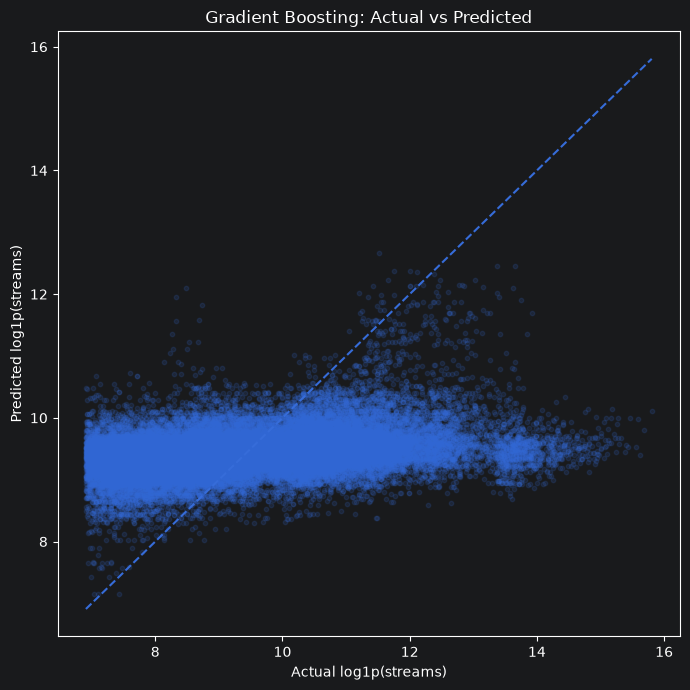

In [19]:
plt.figure(figsize=(7, 7))

plt.scatter(y_test, gradient_prediction, alpha=0.15, s=10)

lower = min(y_test.min(), gradient_prediction.min())
upper = max(y_test.max(), gradient_prediction.max())

plt.plot([lower, upper], [lower, upper], linestyle="--")

plt.xlabel("Actual log1p(streams)")
plt.ylabel("Predicted log1p(streams)")
plt.title("Gradient Boosting: Actual vs Predicted")

plt.tight_layout()
plt.show()

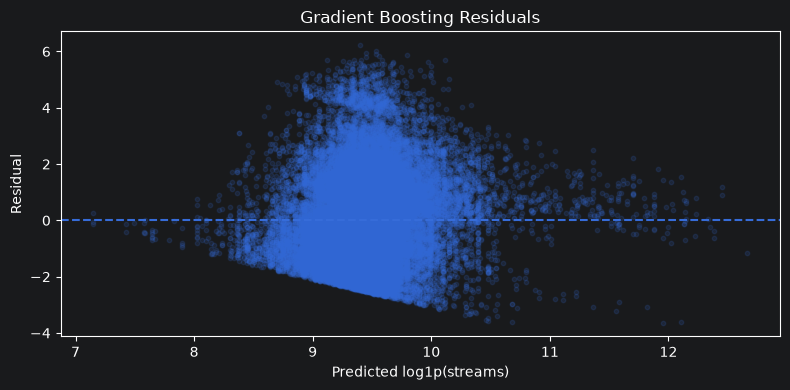

Mean residual: -0.004827149211073369
Residual standard deviation: 1.4770072512041539


In [20]:
residuals = y_test - gradient_prediction

plt.figure(figsize=(8, 4))

plt.scatter(gradient_prediction, residuals, alpha=0.15, s=10)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted log1p(streams)")
plt.ylabel("Residual")
plt.title("Gradient Boosting Residuals")

plt.tight_layout()
plt.show()

print("Mean residual:", residuals.mean())
print("Residual standard deviation:", residuals.std())

In [21]:
example_song = pd.DataFrame([{
    "duration_ms": 210000,
    "explicit": 0,
    "af_danceability": 0.70,
    "af_energy": 0.65,
    "af_key": 5,
    "af_loudness": -6.0,
    "af_mode": 1,
    "af_speechiness": 0.05,
    "af_acousticness": 0.20,
    "af_instrumentalness": 0.00,
    "af_liveness": 0.10,
    "af_valence": 0.60,
    "af_tempo": 120.0,
    "af_time_signature": 4,
}])

example_log_prediction = gradient_model.predict(example_song)[0]
example_stream_prediction = float(np.expm1(example_log_prediction))

print(f"Predicted log1p(streams): {example_log_prediction:.2f}")
print(f"Estimated streams: {example_stream_prediction:,.0f}")

Predicted log1p(streams): 9.42
Estimated streams: 12,281
